# **Matplotlib y gráficos de líneas**

### Conjunto de datos: Inmigración a Canadá entre 1980 y 2013

Fuente del conjunto de datos: [Flujos migratorios internacionales hacia y desde determinados países: revisión de 2015](https://www.un.org/development/desa/pd/data/international-migration-flows).

Nos centraremos en los datos de inmigración de Canadá. <br><br>Ya hemos **preprocesado** los datos; para este ejercicio utilizaremos los **datos limpios** guardados en formato CSV.
El conjunto de datos sobre inmigración en Canadá se puede descargar desde <a href="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv">aquí</a>

Instalar e importar módulos: *pandas*, *numpy* y *matplotlib*

In [13]:
!pip install pandas
!pip install numpy
!pip install matplotlib
import pandas as pd # primary data structure library

Descarga e importación del conjunto de datos principal sobre inmigración canadiense utilizando el método `read_csv()` de *pandas*.

In [14]:
df_can = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv')

print('¡Datos importados a un dataframe de pandas!')

¡Datos importados a un dataframe de pandas!


In [15]:
df_can.head()

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,15


Dado que hemos convertido los años en cadenas de caracteres, declaremos una variable que nos permita acceder fácilmente a todo el rango de años:

In [16]:
years = list(map(str, range(1980, 2014)))
years

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

# **Visualización de datos con Matplotlib**

Empecemos importando `matplotlib` y `matplotlib.pyplot` de la siguiente manera:

In [17]:
# Estamos utilizando el backend «inline»
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

In [18]:
print('Matplotlib version: ', mpl.__version__)  # >= 2.0.0

Matplotlib version:  3.10.0


In [19]:
print(plt.style.available)
mpl.style.use(['ggplot']) # Aplicamos estilo similar a gplot

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


### Creación de gráficos en *pandas*

Documentación:
- [Creación de gráficos con series](http://pandas.pydata.org/pandas-docs/stable/api.html#plotting)<br>
- [Creación de gráficos con marcos de datos](http://pandas.pydata.org/pandas-docs/stable/api.html#api-dataframe-plotting)

# Series/Dataframe

**¿Qué es un gráfico de líneas y para qué sirve?**

Un gráfico de líneas es un tipo de gráfico que muestra la información como una serie de puntos de datos, denominados «marcadores», conectados entre sí mediante segmentos de línea recta. Se trata de un tipo de gráfico básico muy habitual en muchos campos.
Utiliza el gráfico de líneas cuando tengas un conjunto de datos continuos. Estos gráficos son los más adecuados para visualizar tendencias de datos a lo largo de un periodo de tiempo.

**Caso práctico:**

En 2010, Haití sufrió un catastrófico terremoto de magnitud 7,0. El sísmo provocó una devastación generalizada y la pérdida de vidas humanas, y alrededor de tres millones de personas se vieron afectadas por este desastre natural. Como parte de la ayuda humanitaria de Canadá, el Gobierno de Canadá intensificó sus esfuerzos para acoger a refugiados de Haití. Podemos visualizar rápidamente esta iniciativa utilizando un gráfico de `líneas`:

**Pregunta:** Traza un gráfico de líneas que represente la inmigración procedente de Haití utilizando `df.plot()`.

En primer lugar, extraeremos la serie de datos correspondiente a Haití.

In [20]:
df_can.set_index('Country', inplace=True)
#creación de la serie de datos
haiti = df_can.loc['Haiti', years] # pasando los años 1980 - 2013 para excluir la columna «total»
haiti.head()

,Haiti
1980,1666
1981,3692
1982,3498
1983,2860
1984,1418


A continuación, trazaremos un gráfico de líneas añadiendo .plot() al marco de datos «haiti».

<Axes: >

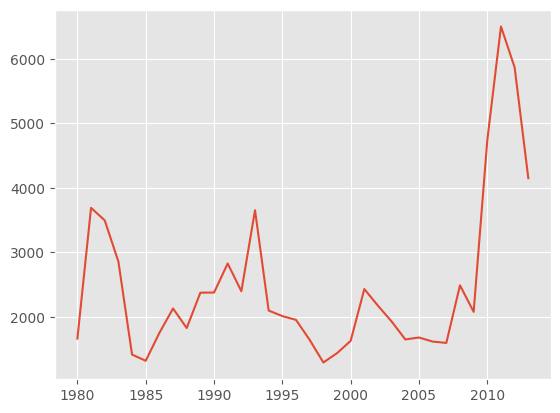

In [21]:
haiti.plot()

*pandas* ha rellenado automáticamente el eje X con los valores del índice (años) y el eje Y con los valores de las columnas (población). <br>

Además, vamos a etiquetar los ejes X e Y utilizando `plt.title()`, `plt.ylabel()` y `plt.xlabel()` de la siguiente manera:

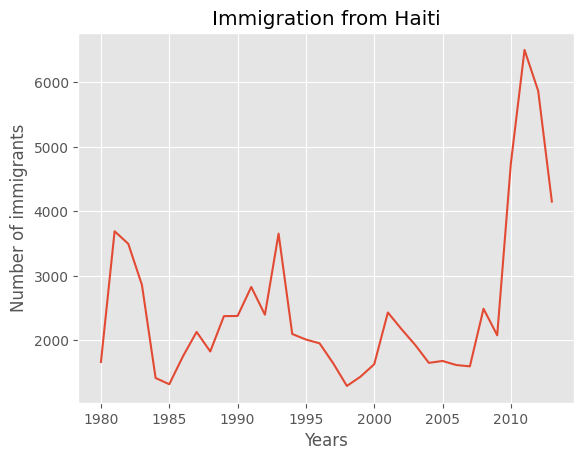

In [22]:
haiti.plot(kind='line')

plt.title('Immigration from Haiti')
plt.ylabel('Number of immigrants')
plt.xlabel('Years')

plt.show() # Esta línea es necesaria para mostrar las modificaciones realizadas en la figura

Podemos observar claramente cómo el número de inmigrantes procedentes de Haití se disparó a partir de 2010, a medida que Canadá intensificaba sus esfuerzos por acoger a refugiados de ese país. Anotemos este pico en el gráfico utilizando el método `plt.text()`.<br>
<br>
Sin embargo, fíjate en que los años son de tipo *cadena*. Primero, cambiemos el tipo de los valores del índice a *entero*.

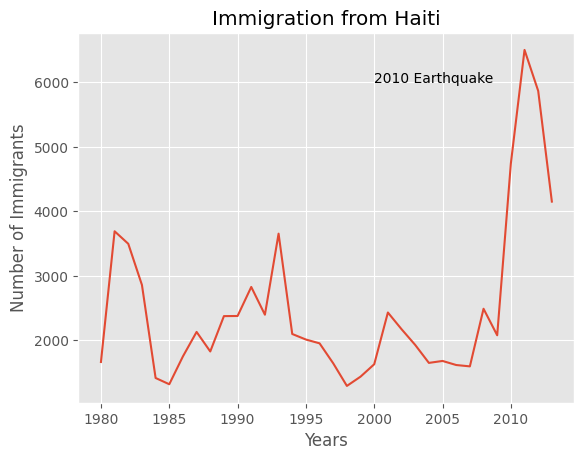

In [23]:
haiti.index = haiti.index.map(int)
haiti.plot(kind='line')

plt.title('Immigration from Haiti')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

# Añadir una etiqueta al terremoto de 2010.
# Sintaxis: plt.text(x, y, etiqueta)
plt.text(2000, 6000, '2010 Earthquake') # véase la nota más abajo

plt.show()

Nota rápida sobre los valores de x e y en `plt.text(x, y, label)`:
    
Dado que el eje x (años) es de tipo «entero», hemos especificado x como un año. El eje y (número de inmigrantes) es de tipo «entero», por lo que basta con especificar el valor y = 6000.
    
```python
    plt.text(2000, 6000, “Terremoto de 2010”) # años almacenados como tipo int
```
Si los años se almacenaran como tipo «cadena», tendríamos que especificar x como la posición en el índice del año. Por ejemplo, el índice 20 corresponde al año 2000, ya que es el vigésimo año tomando como año base el 1980.
```python
    plt.text(20, 6000, “Terremoto de 2010”) # años almacenados como tipo int
```


Podemos añadir fácilmente más países al gráfico de líneas para realizar comparaciones significativas sobre la inmigración procedente de distintos países.

***Comparemos el número de inmigrantes procedentes de la India y de China entre 1980 y 2013.***

Paso 1: Obtén el conjunto de datos de China y la India, y muestra el marco de datos.

In [25]:
df_CI = df_can.loc[['China','India'], years] # pasando los años 1980 - 2013 para excluir la columna «total»
df_CI.head()

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Country,,,,,,,,,,,,,,,,,,,,,
China,5123,6682,3308,1863,1527,1816,1960,2643,2758,4323,...,36619,42584,33518,27642,30037,29622,30391,28502,33024,34129
India,8880,8670,8147,7338,5704,4211,7150,10189,11522,10343,...,28235,36210,33848,28742,28261,29456,34235,27509,30933,33087


Paso 2: Trazar el gráfico. Especificaremos explícitamente un gráfico de líneas pasando el parámetro `kind` a la función `plot()`.

<Axes: xlabel='Country'>

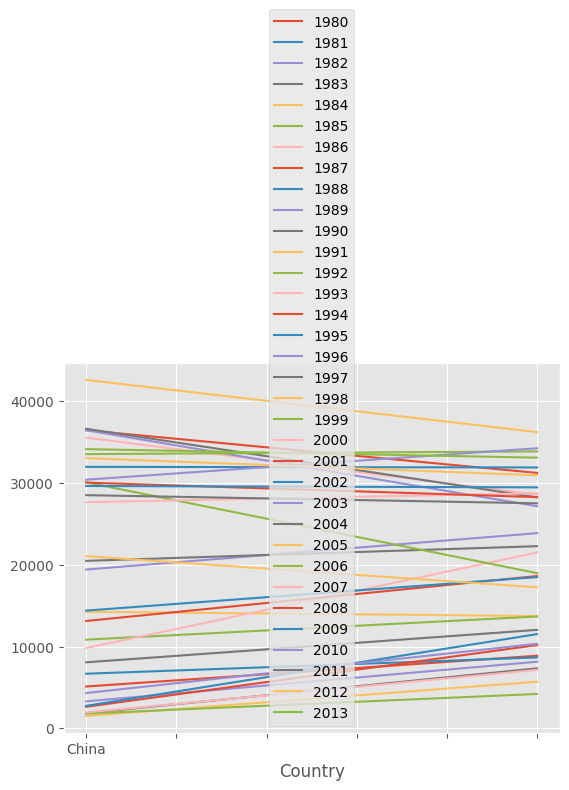

In [27]:
df_CI.plot(kind='line')

Eso no parece correcto...

*Ppandas* representa los índices en el eje x y las columnas como líneas individuales en el eje y. Dado que `df_CI` es un dataframe con `country` como índice y `years` como columnas, primero debemos transponer el dataframe utilizando el método `transpose()` para intercambiar las filas y las columnas.

In [28]:
df_CI = df_CI.transpose()
df_CI.head()

Country,China,India
1980,5123,8880
1981,6682,8670
1982,3308,8147
1983,1863,7338
1984,1527,5704


*pandas* representará automáticamente los datos de ambos países en el mismo gráfico. Adelante, representa gráficamente el nuevo marco de datos transpuesto. Asegúrate de añadir un título al gráfico y de etiquetar los ejes.

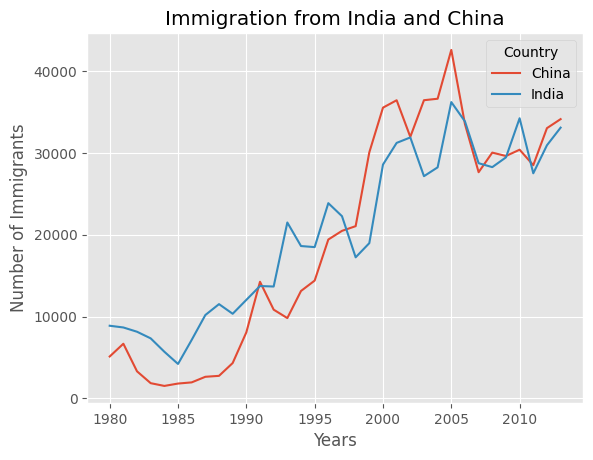

In [30]:
df_CI.index = df_CI.index.map(int)
df_CI.plot(kind='line')

plt.title('Immigration from India and China')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')
plt.show()

***Compara la evolución de los cinco países que más han contribuido a la inmigración en Canadá.***

In [36]:
#Paso 1: Obtener el conjunto de datos. Recordemos que creamos una columna «Total» que calcula la inmigración acumulada por país.
#Ordenaremos esta columna para obtener los 5 países principales utilizando el método sort_values() de pandas.

inplace = True # este parámetro guarda los cambios en el dataframe original df_can
df_can.sort_values(by='Total', ascending=False, axis=0, inplace=True)

# Obtener las 5 primeras entradas
df_top5 = df_can.head(5)

# Transponer el dataframe
df_top5 = df_top5[years].transpose()
print(df_top5)

Country  India  China  United Kingdom of Great Britain and Northern Ireland  \
1980      8880   5123                                              22045      
1981      8670   6682                                              24796      
1982      8147   3308                                              20620      
1983      7338   1863                                              10015      
1984      5704   1527                                              10170      
1985      4211   1816                                               9564      
1986      7150   1960                                               9470      
1987     10189   2643                                              21337      
1988     11522   2758                                              27359      
1989     10343   4323                                              23795      
1990     12041   8076                                              31668      
1991     13734  14255                               

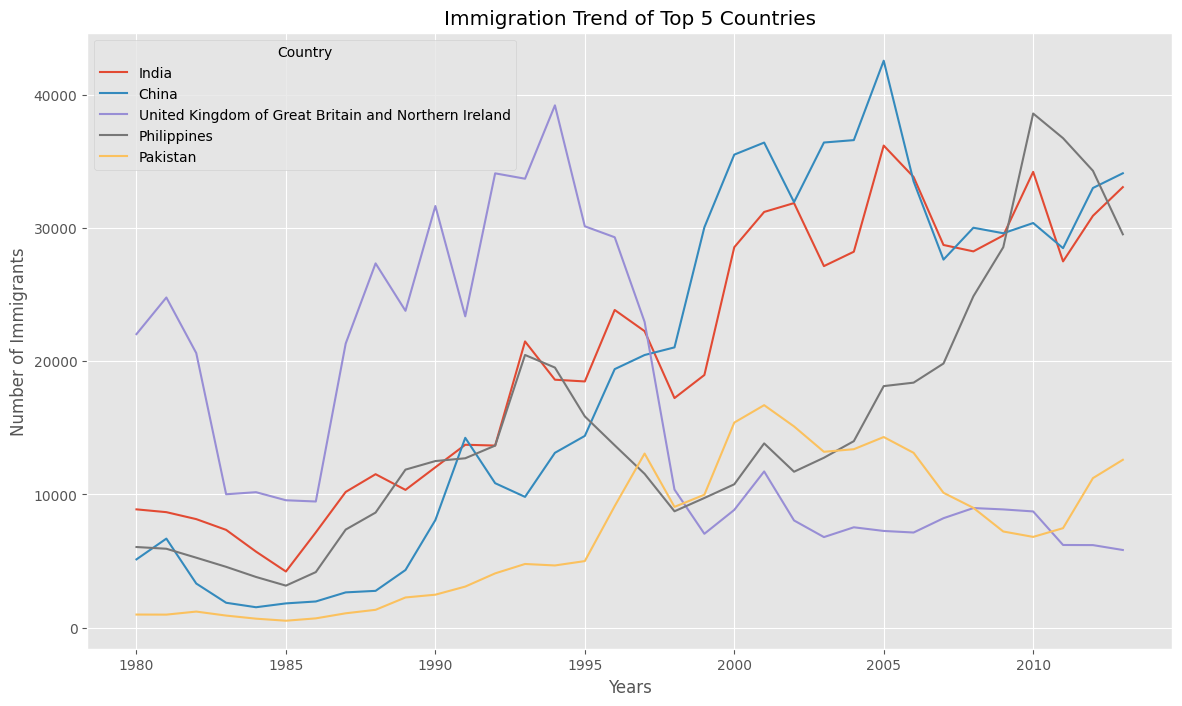

In [33]:
#Paso 2: Trazar el marco de datos. Para que el gráfico sea más legible, cambiaremos el tamaño utilizando el parámetro `figsize`

df_top5.index = df_top5.index.map(int) # cambiemos los valores del índice de df_top5 a tipo entero para el trazado
df_top5.plot(kind='line', figsize=(14, 8)) # pasamos una tupla (x, y) con el tamaño

plt.title('Immigration Trend of Top 5 Countries')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

plt.show()